In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

df = pd.read_csv(r"C:\Users\maryb\Downloads\Churn_data.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# TotalCharges is stored as text (object), not a number -- that's a sign something's off
bad_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print(f"{len(bad_rows)} rows have a non-numeric TotalCharges value")
bad_rows[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

0 rows have a non-numeric TotalCharges value


,tenure,MonthlyCharges,TotalCharges,Churn


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
print("Cleaned. TotalCharges dtype now:", df["TotalCharges"].dtype)

Cleaned. TotalCharges dtype now: float64


In [13]:
churn_rate = df["Churn"].eq("Yes").mean()
print(f"Overall churn rate: {churn_rate*100:.1f}%")
print(f"Churned customers: {df['Churn'].eq('Yes').sum():,} of {len(df):,}")

Overall churn rate: 26.5%
Churned customers: 1,869 of 7,043


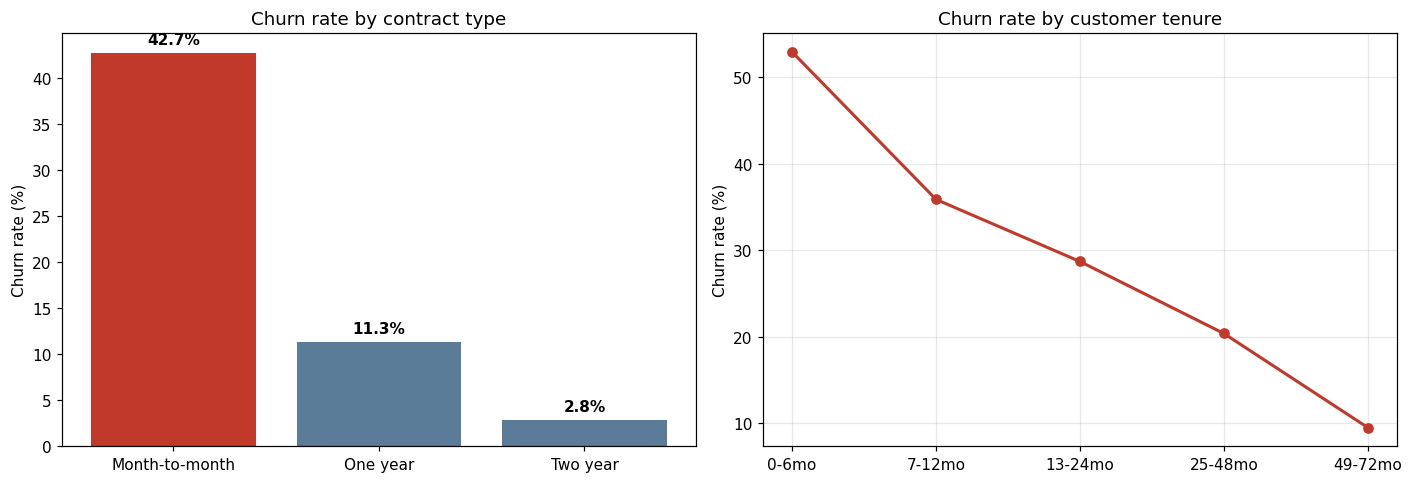

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

contract_churn = df.groupby("Contract")["Churn"].apply(lambda s: s.eq("Yes").mean()*100).reindex(
    ["Month-to-month", "One year", "Two year"])
colors = ["#C0392B" if v == contract_churn.max() else "#5B7C99" for v in contract_churn]
axes[0].bar(contract_churn.index, contract_churn.values, color=colors)
axes[0].set_ylabel("Churn rate (%)")
axes[0].set_title("Churn rate by contract type")
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

df["tenure_bucket"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                              labels=["0-6mo", "7-12mo", "13-24mo", "25-48mo", "49-72mo"])
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].apply(lambda s: s.eq("Yes").mean()*100)
axes[1].plot(tenure_churn.index, tenure_churn.values, marker="o", color="#C0392B", linewidth=2)
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_title("Churn rate by customer tenure")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("churn_by_contract_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

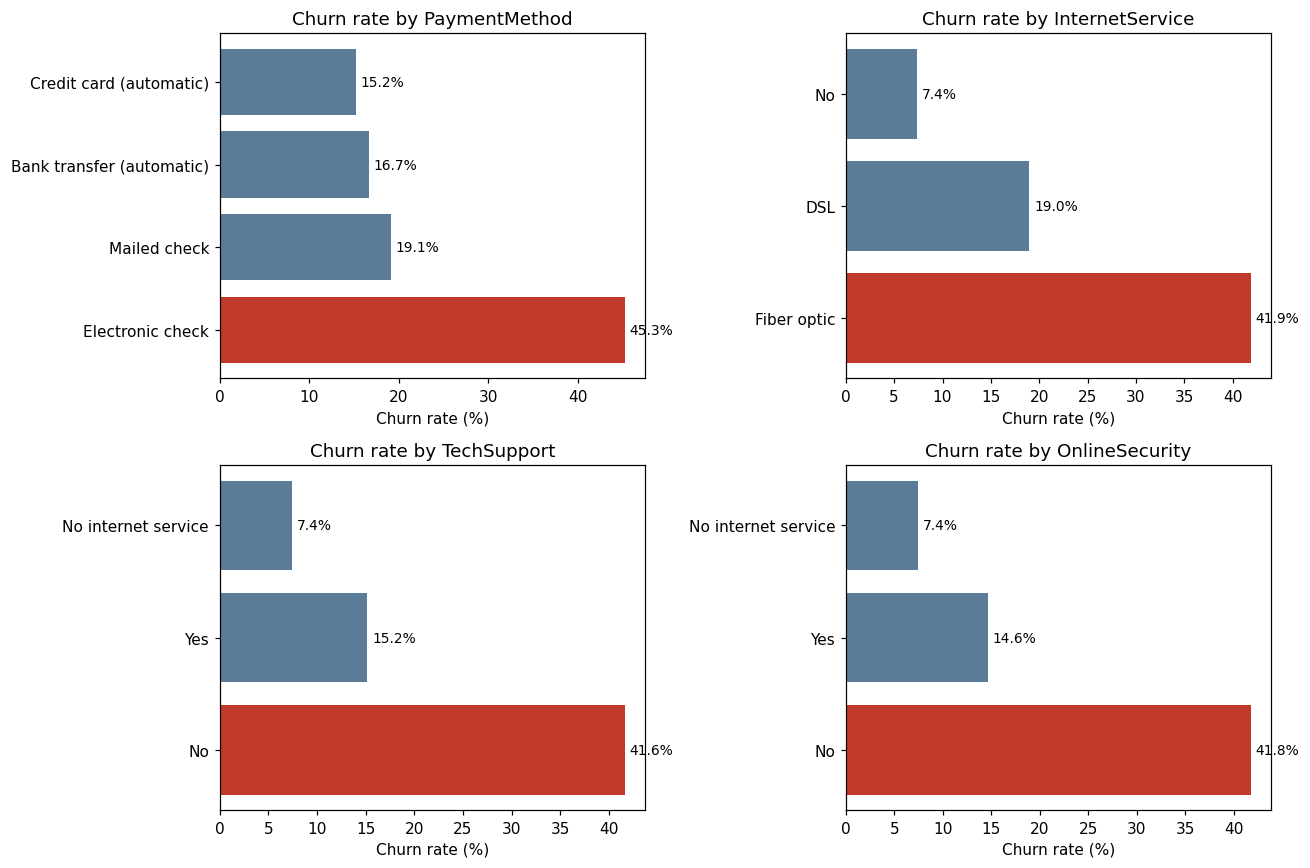

In [15]:
service_cols = ["PaymentMethod", "InternetService", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, service_cols):
    rates = df.groupby(col)["Churn"].apply(lambda s: s.eq("Yes").mean()*100).sort_values(ascending=False)
    colors = ["#C0392B" if v == rates.max() else "#5B7C99" for v in rates]
    ax.barh(rates.index, rates.values, color=colors)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate (%)")
    for i, v in enumerate(rates.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("churn_by_service.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
baseline = churn_rate * 100

combo1 = df[(df.Contract == "Month-to-month") & (df.InternetService == "Fiber optic")]
combo2 = df[(df.Contract == "Month-to-month") & (df.InternetService == "Fiber optic") & (df.TechSupport == "No")]

print(f"Baseline (all customers):                                   {baseline:.1f}% churn")
print(f"Month-to-month + Fiber optic:                                {combo1['Churn'].eq('Yes').mean()*100:.1f}% churn  (n={len(combo1):,})")
print(f"Month-to-month + Fiber optic + No tech support:              {combo2['Churn'].eq('Yes').mean()*100:.1f}% churn  (n={len(combo2):,})")

Baseline (all customers):                                   26.5% churn
Month-to-month + Fiber optic:                                54.6% churn  (n=2,128)
Month-to-month + Fiber optic + No tech support:              57.5% churn  (n=1,796)


In [17]:
monthly_lost = df.loc[df.Churn == "Yes", "MonthlyCharges"].sum()
pct_of_revenue = monthly_lost / df["MonthlyCharges"].sum() * 100

q75 = df["MonthlyCharges"].quantile(0.75)
high_value = df[df["MonthlyCharges"] >= q75]
hv_churn_rate = high_value["Churn"].eq("Yes").mean() * 100
hv_revenue_at_risk = high_value.loc[high_value.Churn == "Yes", "MonthlyCharges"].sum()

print(f"Monthly revenue lost to churned customers: ${monthly_lost:,.0f}  ({pct_of_revenue:.1f}% of total monthly revenue)")
print(f"Annualized:                                ${monthly_lost*12:,.0f}")
print()
print(f"High-value customers (top 25% by monthly charge, >= ${q75:.2f}/mo):")
print(f"  Churn rate: {hv_churn_rate:.1f}%  (vs {baseline:.1f}% baseline)")
print(f"  Monthly revenue at risk from this group alone: ${hv_revenue_at_risk:,.0f}")

Monthly revenue lost to churned customers: $139,131  (30.5% of total monthly revenue)
Annualized:                                $1,669,570

High-value customers (top 25% by monthly charge, >= $89.85/mo):
  Churn rate: 32.7%  (vs 26.5% baseline)
  Monthly revenue at risk from this group alone: $57,683


In [18]:
baseline_accuracy = 1 - churn_rate
print(f"Naive 'never churns' baseline accuracy: {baseline_accuracy*100:.1f}%")
print("This baseline scores misleadingly high on accuracy alone because churn is imbalanced (73.5% / 26.5%).")
print("It has 0% recall on churners, though -- it would miss every single customer actually at risk.")
print("So accuracy alone is not a fair way to judge these models -- recall and ROC-AUC matter more here.")

Naive 'never churns' baseline accuracy: 73.5%
This baseline scores misleadingly high on accuracy alone because churn is imbalanced (73.5% / 26.5%).
It has 0% recall on churners, though -- it would miss every single customer actually at risk.
So accuracy alone is not a fair way to judge these models -- recall and ROC-AUC matter more here.


In [19]:
X = df.drop(columns=["Churn", "tenure_bucket"])
y = df["Churn"].map({"Yes": 1, "No": 0})

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print(f"Train: {len(X_train):,} rows   Test: {len(X_test):,} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}%   Test churn rate: {y_test.mean()*100:.1f}%")

Train: 5,634 rows   Test: 1,409 rows
Train churn rate: 26.5%   Test churn rate: 26.5%


In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42,
                              eval_metric="logloss", scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.806,0.657,0.559,0.604,0.842
1,Random Forest,0.806,0.681,0.503,0.578,0.842
2,XGBoost,0.750,0.520,0.778,0.623,0.836


Best model by ROC-AUC: Logistic Regression


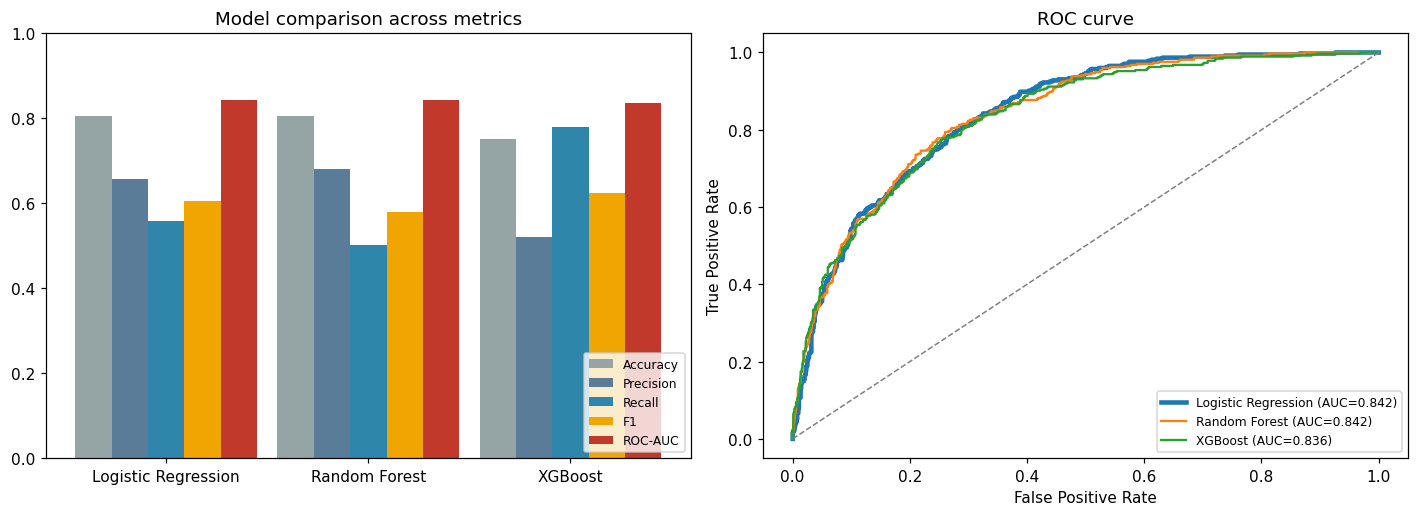

In [21]:
best_name = results_df.loc[0, "Model"]
print(f"Best model by ROC-AUC: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

x = np.arange(len(results_df))
width = 0.18
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
colors_m = ["#95A5A6", "#5B7C99", "#2E86AB", "#F0A500", "#C0392B"]
for i, m in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, results_df[m], width, label=m, color=colors_m[i])
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(results_df["Model"])
axes[0].set_ylim(0, 1)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_title("Model comparison across metrics")

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw = 3 if name == best_name else 1.5
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=lw)
axes[1].plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

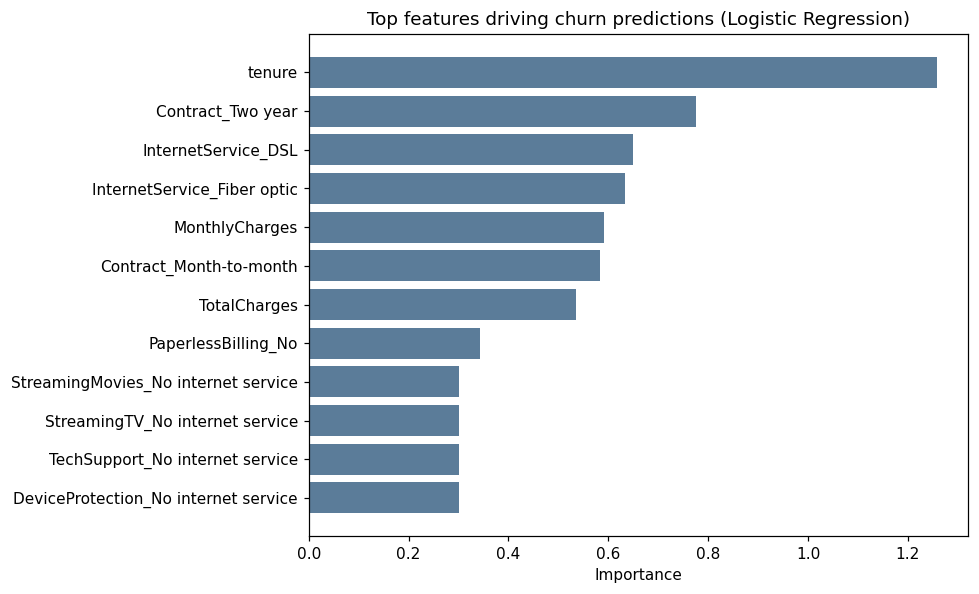

,feature,importance
0,tenure,1.257539
38,Contract_Two year,0.776594
15,InternetService_DSL,0.648646
16,InternetService_Fiber optic,0.634195
1,MonthlyCharges,0.591863
36,Contract_Month-to-month,0.582883
2,TotalCharges,0.536253
39,PaperlessBilling_No,0.343227
34,StreamingMovies_No internet service,0.300104
31,StreamingTV_No internet service,0.300104


In [22]:
best_model = models[best_name]
best_pipe = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
best_pipe.fit(X_train, y_train)

feature_names = (numeric_features +
                  list(best_pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)))

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False).head(12)

plt.figure(figsize=(9, 5.5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#5B7C99")
plt.title(f"Top features driving churn predictions ({best_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df